In [1]:
import pandas as pd

df = pd.read_csv("clean_crypto_data.csv")
df.head()

,date,coin,price,market_cap,volume,return,volatility_7d,ma_7,ma_30
0,2026-01-09 12:01:30.219,binancecoin,889.454177,1.225755e+11,1.162151e+09,0.000295,0.002143,891.388532,888.521924
1,2026-01-09 13:02:51.349,binancecoin,888.468414,1.223877e+11,1.097274e+09,-0.001108,0.001865,890.301389,888.819270
2,2026-01-09 14:03:52.388,binancecoin,889.416079,1.225590e+11,1.115885e+09,0.001067,0.002056,889.500829,889.005301
3,2026-01-09 15:02:39.447,binancecoin,886.204109,1.220709e+11,1.084611e+09,-0.003611,0.002237,888.559870,889.131787
4,2026-01-09 16:02:26.434,binancecoin,893.866451,1.229358e+11,1.128109e+09,0.008646,0.004039,889.147591,889.526780


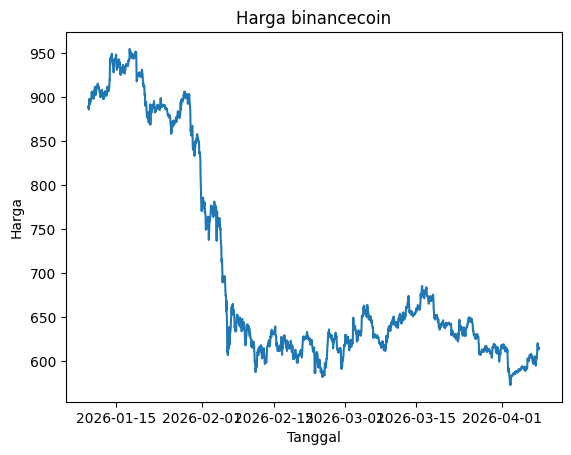

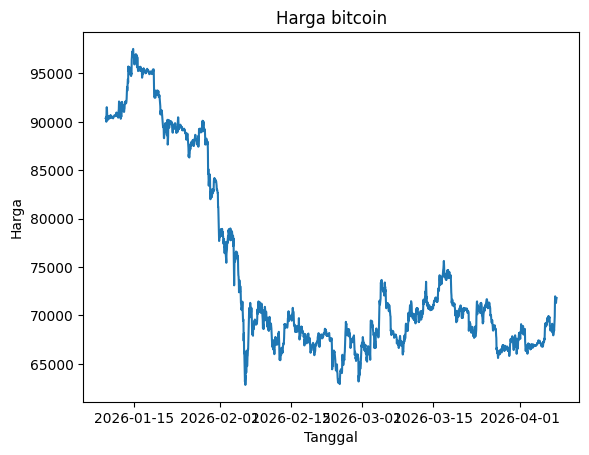

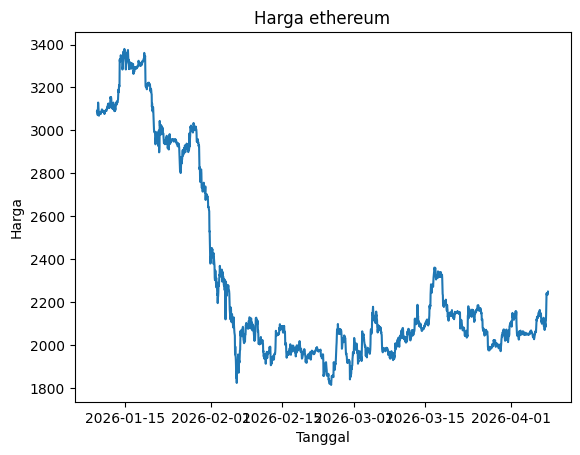

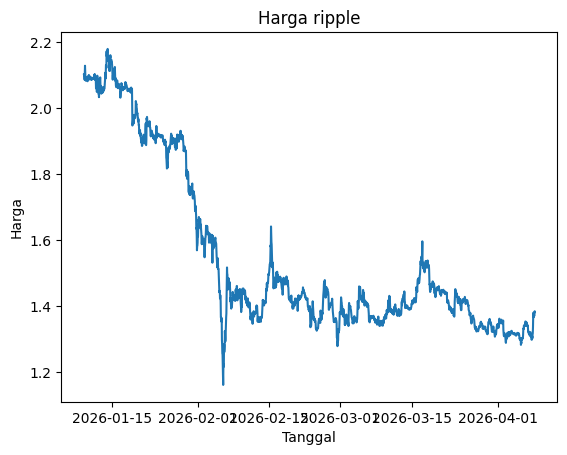

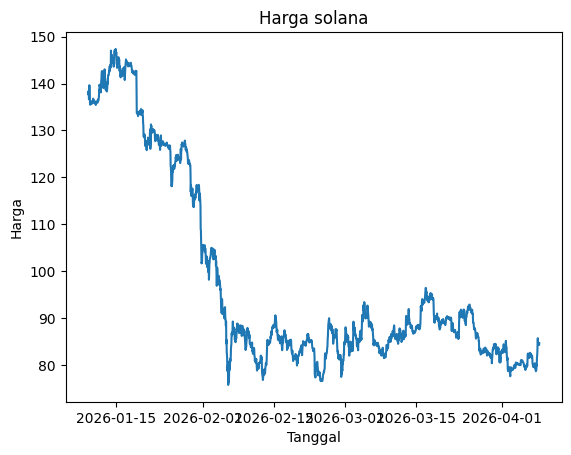

In [2]:
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

for coin in df["coin"].unique():
    subset = df[df["coin"] == coin]

    plt.figure()
    plt.plot(subset["date"], subset["price"])
    plt.title(f"Harga {coin}")
    plt.xlabel("Tanggal")
    plt.ylabel("Harga")
    plt.show()

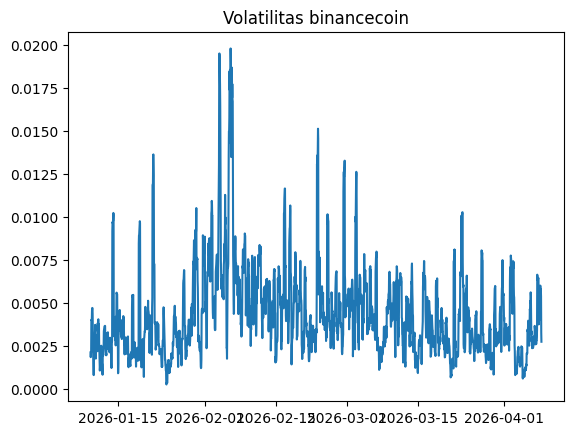

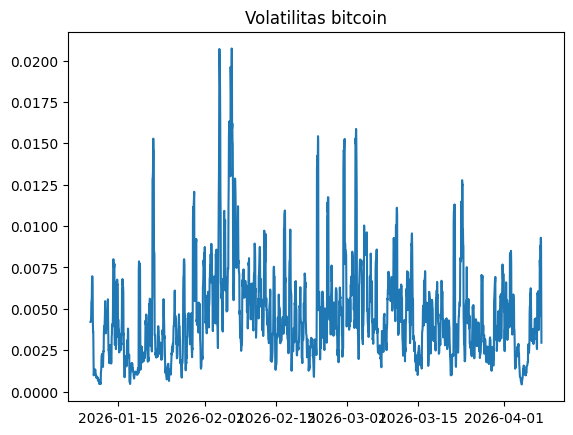

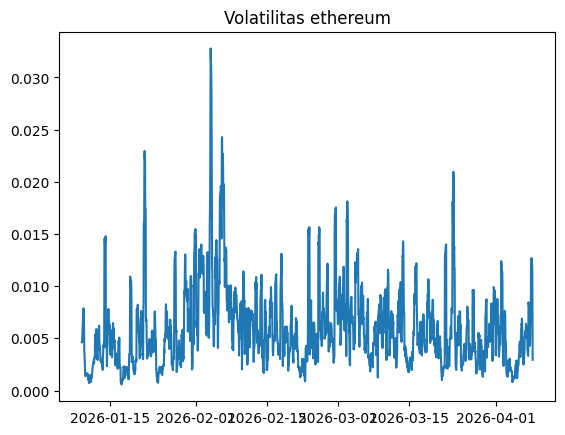

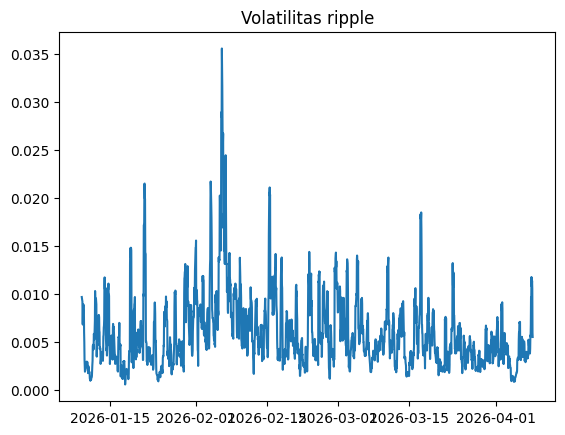

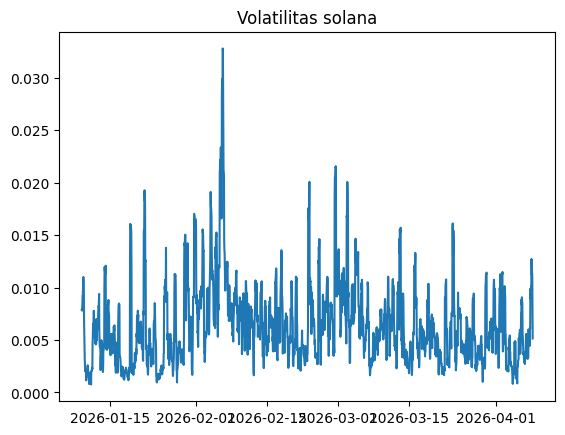

In [3]:
for coin in df["coin"].unique():
    subset = df[df["coin"] == coin]

    plt.figure()
    plt.plot(subset["date"], subset["volatility_7d"])
    plt.title(f"Volatilitas {coin}")
    plt.show()

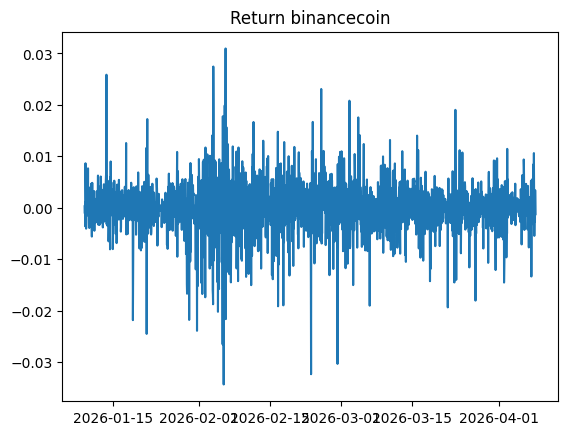

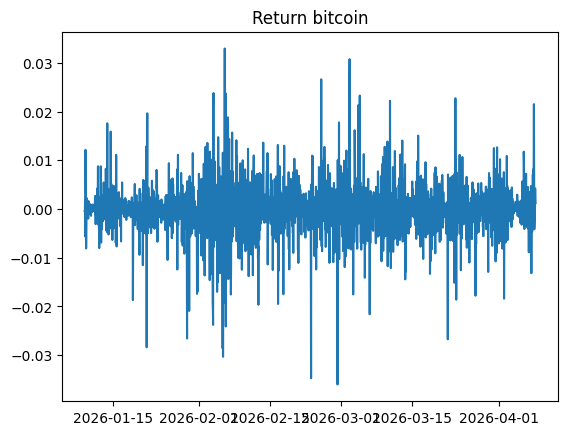

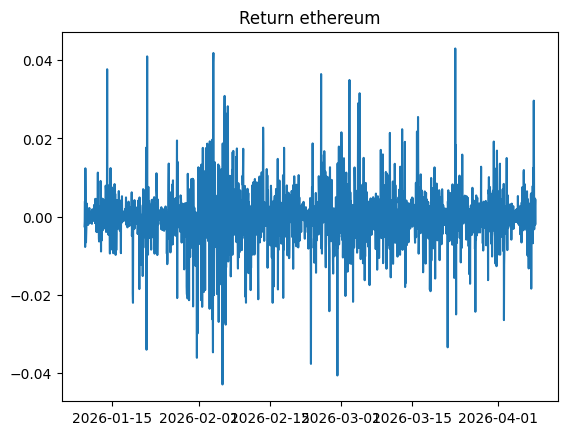

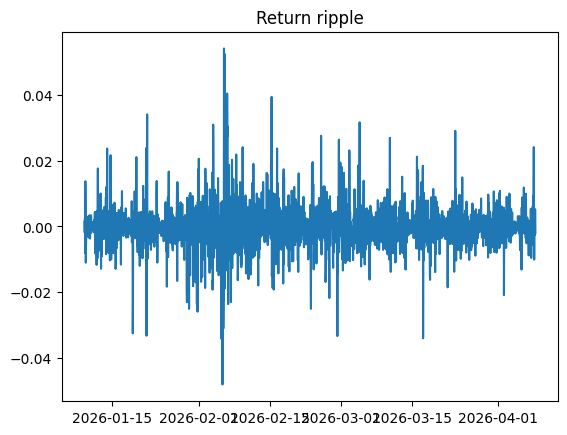

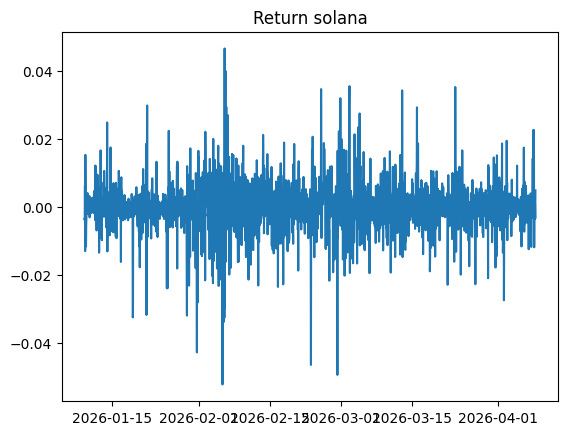

In [4]:
for coin in df["coin"].unique():
    subset = df[df["coin"] == coin]

    plt.figure()
    plt.plot(subset["date"], subset["return"])
    plt.title(f"Return {coin}")
    plt.show()

Dari Visualisasi diatas, dapat disimpulkan bahwa,

1. Harga cryptocurrency menunjukkan fluktuasi tinggi dalam periode 90 hari
2. Volatilitas meningkat saat terjadi perubahan harga ekstrem
3. Return menunjukkan adanya pergerakan naik dan turun yang signifikan dalam jangka pendek
4. Setiap cryptocurrency memiliki pola pergerakan yang berbeda

dan konsep big data yang kelompok kami terapkan yaitu sebagai berikut,
- Volume → data ribuan karena hourly + multi crypto
- Velocity → data diambil dari API (real-time)
- Variety → price, volume, market cap, return, volatility
- Veracity → preprocessing & cleaning data
- Value → insight + prediksi + dashboard

In [5]:
!pip install scikit-learn

In [6]:
import pandas as pd

df = pd.read_csv("clean_crypto_data.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,coin,price,market_cap,volume,return,volatility_7d,ma_7,ma_30
0,2026-01-09 12:01:30.219,binancecoin,889.454177,1.225755e+11,1.162151e+09,0.000295,0.002143,891.388532,888.521924
1,2026-01-09 13:02:51.349,binancecoin,888.468414,1.223877e+11,1.097274e+09,-0.001108,0.001865,890.301389,888.819270
2,2026-01-09 14:03:52.388,binancecoin,889.416079,1.225590e+11,1.115885e+09,0.001067,0.002056,889.500829,889.005301
3,2026-01-09 15:02:39.447,binancecoin,886.204109,1.220709e+11,1.084611e+09,-0.003611,0.002237,888.559870,889.131787
4,2026-01-09 16:02:26.434,binancecoin,893.866451,1.229358e+11,1.128109e+09,0.008646,0.004039,889.147591,889.526780


In [19]:
from sklearn.model_selection import train_test_split

features = ["return", "volatility_7d", "ma_7", "ma_30"]
target = "price"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [22]:
y_pred = model.predict(X_test)

In [33]:
import pandas as pd

hasil = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

hasil.head(10)

,Actual,Predicted
0,2,2
1,2,2
2,2,2
3,0,0
4,1,1
5,2,2
6,2,2
7,0,0
8,2,2
9,2,2


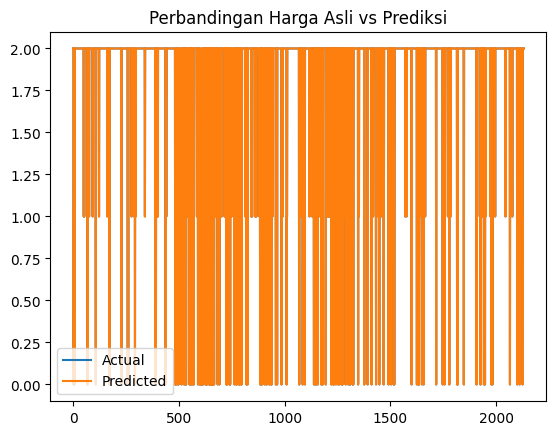

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Perbandingan Harga Asli vs Prediksi")
plt.show()

In [30]:
data_terakhir = X.iloc[-1:]

prediksi = model.predict(data_terakhir)

print("Prediksi harga berikutnya:", prediksi[0])

Prediksi harga berikutnya: 2.1439443659844786


In [23]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 9585.185041312738


In [24]:
def label_market(x):
    if x > 0.01:
        return "bullish"
    elif x < -0.01:
        return "bearish"
    else:
        return "sideways"

df["market_phase"] = df["return"].apply(label_market)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["market_phase_encoded"] = le.fit_transform(df["market_phase"])

In [26]:
from sklearn.ensemble import RandomForestClassifier

X = df[features]
y = df["market_phase_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [27]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [37]:
hasil_clf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

hasil_clf.head()

,Actual,Predicted
8531,2,2
8532,2,2
8533,2,2
8534,0,0
8535,1,1


In [38]:
hasil_clf["Actual_label"] = le.inverse_transform(hasil_clf["Actual"])
hasil_clf["Predicted_label"] = le.inverse_transform(hasil_clf["Predicted"])

hasil_clf.head(10)

,Actual,Predicted,Actual_label,Predicted_label
8531,2,2,sideways,sideways
8532,2,2,sideways,sideways
8533,2,2,sideways,sideways
8534,0,0,bearish,bearish
8535,1,1,bullish,bullish
8536,2,2,sideways,sideways
8537,2,2,sideways,sideways
8538,0,0,bearish,bearish
8539,2,2,sideways,sideways
8540,2,2,sideways,sideways


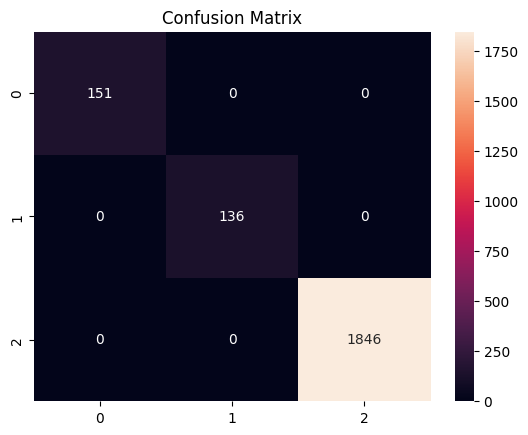

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()